# Wine Quality Data Workflow

**Author:** Dennis O'Higgins

**Dataset:** Wine Quality (red and white Portuguese Vinho Verde wines), UCI Machine Learning Repository. Source: https://archive.ics.uci.edu/dataset/186/wine+quality

**Project description:** This project builds a complete and reproducible Python data workflow that loads, cleans, explores and visualises physicochemical measurements and expert sensory quality scores for red and white Vinho Verde wines. The aim is to understand which chemical properties are most strongly associated with quality ratings, and to document every step so that the workflow can be reused as the foundation for later machine learning projects. No models are trained in this notebook.

**Structure:** 1. Setup, 2. Data Ingestion, 3. Data Cleaning, 4. Exploratory Data Analysis (EDA), 5. Visualizations, 6. Summary and Interpretation.

## 1. Setup

This section imports the libraries used in the workflow (NumPy, pandas, Matplotlib and Seaborn), sets a consistent plotting style and defines the file locations. Paths are relative so the notebook runs from the repository folder on any machine.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

RED_PATH = "winequality-red.csv"
WHITE_PATH = "winequality-white.csv"
FIGURE_DIR = "figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

print("NumPy", np.__version__, "| pandas", pd.__version__, "| Matplotlib", plt.matplotlib.__version__, "| Seaborn", sns.__version__)

NumPy 2.2.6 | pandas 2.3.3 | Matplotlib 3.10.9 | Seaborn 0.13.2


## 2. Data Ingestion

The UCI Wine Quality data is distributed as two semicolon-separated files, one for red wines and one for white wines. The function below reads both files, adds a `wine_type` column so the origin of each row is not lost, and stacks them into a single DataFrame.

In [2]:
def load_wine_data(red_path, white_path):
    """Load the red and white wine CSV files and combine them into one DataFrame.

    Both files are semicolon-separated. A `wine_type` column ("red" or "white")
    is added to each file before the two are concatenated, so the colour of the
    wine remains available for grouping and comparison.

    Parameters
    ----------
    red_path : str
        Path to winequality-red.csv.
    white_path : str
        Path to winequality-white.csv.

    Returns
    -------
    pandas.DataFrame
        The combined raw data with a new `wine_type` column.
    """
    red = pd.read_csv(red_path, sep=";")
    white = pd.read_csv(white_path, sep=";")
    red["wine_type"] = "red"
    white["wine_type"] = "white"
    return pd.concat([red, white], ignore_index=True)


df = load_wine_data(RED_PATH, WHITE_PATH)
print("Rows, columns:", df.shape)
df.head()

Rows, columns: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


## 3. Data Cleaning

**Why cleaning is needed.** The raw files are tidy, but a quick inspection shows four issues that would cause problems later in a reproducible workflow:

1. Column names contain spaces and mixed styles (for example `fixed acidity`, `pH`), which makes code harder to write and less consistent.
2. The data may contain exact duplicate rows, which would give some wines extra weight in any summary statistic or model.
3. Although the documentation reports no missing values, this should be checked in code rather than assumed, together with impossible values (for example a pH outside 0 to 14).
4. The quality score is an integer from 0 to 10 that is easier to interpret in broad bands (low, medium, high) for comparisons.

The functions below address each issue. Each one has a docstring that explains what it does.

In [4]:
def standardise_column_names(frame):
    """Return a copy of the DataFrame with consistent snake_case column names.

    Leading and trailing whitespace is removed, text is lower-cased and spaces
    are replaced with underscores (for example "fixed acidity" becomes
    "fixed_acidity"). This keeps column access consistent throughout the
    notebook.
    """
    cleaned = frame.copy()
    cleaned.columns = [c.strip().lower().replace(" ", "_") for c in cleaned.columns]
    return cleaned


def check_data_quality(frame):
    """Report basic data quality indicators for a wine DataFrame.

    The report counts missing cells, exact duplicate rows, negative values in
    the numeric columns, pH values outside the physical range 0 to 14, and
    quality scores outside the documented 0 to 10 scale.

    Returns
    -------
    pandas.Series
        One entry per check. All entries except `rows` and `columns` should be
        zero for a clean dataset, apart from `duplicate_rows`, which is handled
        by `drop_exact_duplicates`.
    """
    numeric = frame.select_dtypes(include="number")
    return pd.Series({
        "rows": len(frame),
        "columns": frame.shape[1],
        "missing_cells": int(frame.isna().sum().sum()),
        "duplicate_rows": int(frame.duplicated().sum()),
        "negative_values": int((numeric < 0).sum().sum()),
        "ph_outside_0_14": int((~frame["ph"].between(0, 14)).sum()),
        "quality_outside_0_10": int((~frame["quality"].between(0, 10)).sum()),
    })


def drop_exact_duplicates(frame):
    """Remove rows that are exact duplicates of an earlier row.

    Returns
    -------
    tuple of (pandas.DataFrame, int)
        The de-duplicated DataFrame with a reset index, and the number of rows
        removed. The first occurrence of each duplicated row is kept.
    """
    deduplicated = frame.drop_duplicates().reset_index(drop=True)
    return deduplicated, len(frame) - len(deduplicated)


def add_quality_band(frame):
    """Return a copy of the DataFrame with an ordered `quality_band` column.

    Quality scores of 5 or below are labelled "low", a score of 6 is "medium"
    and scores of 7 or above are "high". The column is an ordered categorical
    so that plots and tables list the bands in a meaningful order.
    """
    banded = frame.copy()
    banded["quality_band"] = pd.cut(
        banded["quality"],
        bins=[-1, 5, 6, 10],
        labels=["low", "medium", "high"],
        ordered=True,
    )
    return banded

In [5]:
# Step 1: consistent column names
clean_df = standardise_column_names(df)
print(list(clean_df.columns))

# Step 2: data quality report before de-duplication
report_before = check_data_quality(clean_df)
print()
print(report_before)

# Step 3: duplicates, reported by wine type so any uneven impact is visible
duplicates_by_type = clean_df[clean_df.duplicated()].groupby("wine_type").size()
share_removed = (duplicates_by_type / clean_df.groupby("wine_type").size() * 100).round(1)
print()
print("Duplicate rows by wine type:", duplicates_by_type.to_dict())
print("Share of each wine type removed (%):", share_removed.to_dict())

# Step 4: remove duplicates and add the quality band
clean_df, n_removed = drop_exact_duplicates(clean_df)
clean_df = add_quality_band(clean_df)
print()
print("Rows removed:", n_removed, "| Rows remaining:", len(clean_df))
clean_df.head()

['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'ph', 'sulphates', 'alcohol', 'quality', 'wine_type']

rows                    6497
columns                   13
missing_cells              0
duplicate_rows          1177
negative_values            0
ph_outside_0_14            0
quality_outside_0_10       0
dtype: int64

Duplicate rows by wine type: {'red': 240, 'white': 937}
Share of each wine type removed (%): {'red': 15.0, 'white': 19.1}

Rows removed: 1177 | Rows remaining: 5320


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,wine_type,quality_band
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,low
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red,low
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red,low
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red,medium
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,red,low


In [6]:
# Sensitivity check: does removing duplicates change the average quality by wine type?
raw_means = standardise_column_names(df).groupby("wine_type")["quality"].mean().round(3)
clean_means = clean_df.groupby("wine_type")["quality"].mean().round(3)
pd.DataFrame({"mean_quality_raw": raw_means, "mean_quality_clean": clean_means,
              "difference": (clean_means - raw_means).round(3)})

,mean_quality_raw,mean_quality_clean,difference
wine_type,,,
red,5.636,5.623,-0.013
white,5.878,5.855,-0.023


**Cleaning justification and results.** The check confirmed that there are no missing cells, no negative values, no impossible pH values and no quality scores outside the 0 to 10 scale, so no imputation or row deletion for missing data was necessary. The only substantive issue was 1,177 exact duplicate rows (240 red and 937 white). I removed them because duplicated rows would count the same measurements more than once in every later summary. This choice rests on an assumption: two different wines could in principle share identical measurements and ratings, so some removed rows may be genuine separate samples. The sensitivity check shows that removing duplicates changes the mean quality of each wine type by less than 0.03 points, which suggests the decision does not materially distort the findings. Removal was uneven across types (about 15.0 percent of red rows and 19.1 percent of white rows), which is noted as a limitation in the summary below. Outliers were kept, because extreme values such as very high residual sugar are chemically possible and removing them without domain advice could discard real wines.

## 4. Exploratory Data Analysis (EDA)

The functions below produce the numerical summaries that guide the visualizations: descriptive statistics for every numeric feature, quality grouped by wine type or quality band, and a ranking of how strongly each feature is correlated with quality. Spearman correlation is reported alongside Pearson because quality is an ordered score, not a continuous measurement.

In [7]:
def summarise_numeric_features(frame):
    """Return descriptive statistics for every numeric column.

    The table has one row per feature with the count, mean, standard
    deviation, minimum, quartiles and maximum, rounded to three decimals.
    """
    return frame.select_dtypes(include="number").describe().T.round(3)


def summarise_by_group(frame, group_col, value_cols):
    """Return the mean and count of selected columns for each value of a grouping column.

    Parameters
    ----------
    frame : pandas.DataFrame
        The cleaned data.
    group_col : str
        Column to group by (for example "wine_type" or "quality_band").
    value_cols : list of str
        Numeric columns whose group means are reported.

    Returns
    -------
    pandas.DataFrame
        One row per group with a `count` column and the mean of each value column.
    """
    grouped = frame.groupby(group_col, observed=True)
    summary = grouped[value_cols].mean().round(3)
    summary.insert(0, "count", grouped.size())
    return summary


def rank_feature_correlations(frame, target="quality"):
    """Rank numeric features by their correlation with a target column.

    Both Pearson (linear) and Spearman (rank-based) coefficients are computed.
    The result is sorted by the Spearman coefficient from most negative to most
    positive.
    """
    numeric = frame.select_dtypes(include="number")
    pearson = numeric.corr(method="pearson")[target]
    spearman = numeric.corr(method="spearman")[target]
    result = pd.DataFrame({"pearson": pearson, "spearman": spearman}).drop(index=target)
    return result.sort_values("spearman").round(3)

In [8]:
summarise_numeric_features(clean_df)

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,5320.0,7.215,1.320,3.800,6.400,7.000,7.700,15.900
volatile_acidity,5320.0,0.344,0.168,0.080,0.230,0.300,0.410,1.580
citric_acid,5320.0,0.318,0.147,0.000,0.240,0.310,0.400,1.660
residual_sugar,5320.0,5.048,4.500,0.600,1.800,2.700,7.500,65.800
chlorides,5320.0,0.057,0.037,0.009,0.038,0.047,0.066,0.611
free_sulfur_dioxide,5320.0,30.037,17.805,1.000,16.000,28.000,41.000,289.000
total_sulfur_dioxide,5320.0,114.109,56.774,6.000,74.000,116.000,153.250,440.000
density,5320.0,0.995,0.003,0.987,0.992,0.995,0.997,1.039
ph,5320.0,3.225,0.160,2.720,3.110,3.210,3.330,4.010
sulphates,5320.0,0.533,0.150,0.220,0.430,0.510,0.600,2.000


In [9]:
print("Quality score counts:")
print(clean_df["quality"].value_counts().sort_index().to_dict())
print()
print("Share of wines in each quality band by wine type:")
print(pd.crosstab(clean_df["wine_type"], clean_df["quality_band"], normalize="index").round(3))

Quality score counts:
{3: 30, 4: 206, 5: 1752, 6: 2323, 7: 856, 8: 148, 9: 5}

Share of wines in each quality band by wine type:
quality_band    low  medium   high
wine_type                         
red           0.471   0.394  0.135
white         0.340   0.451  0.208


In [10]:
features = ["alcohol", "density", "volatile_acidity", "chlorides", "residual_sugar", "total_sulfur_dioxide"]
print("Mean of key features by wine type:")
display(summarise_by_group(clean_df, "wine_type", features))
print("Mean of key features by quality band:")
display(summarise_by_group(clean_df, "quality_band", features))

Mean of key features by wine type:


,count,alcohol,density,volatile_acidity,chlorides,residual_sugar,total_sulfur_dioxide
wine_type,,,,,,,
red,1359,10.432,0.997,0.529,0.088,2.523,46.826
white,3961,10.589,0.994,0.281,0.046,5.915,137.194


Mean of key features by quality band:


,count,alcohol,density,volatile_acidity,chlorides,residual_sugar,total_sulfur_dioxide
quality_band,,,,,,,
low,1988,9.913,0.996,0.403,0.066,5.327,117.738
medium,2323,10.649,0.994,0.316,0.054,5.153,114.433
high,1009,11.573,0.993,0.294,0.044,4.259,106.211


In [11]:
correlations = rank_feature_correlations(clean_df)
correlations

,pearson,spearman
density,-0.326,-0.349
chlorides,-0.202,-0.304
volatile_acidity,-0.265,-0.251
fixed_acidity,-0.080,-0.104
total_sulfur_dioxide,-0.050,-0.058
residual_sugar,-0.057,-0.028
sulphates,0.042,0.036
ph,0.040,0.053
free_sulfur_dioxide,0.054,0.090
citric_acid,0.098,0.116


**EDA observations.** After cleaning there are 5,320 wines (1,359 red and 3,961 white). Quality scores are concentrated in the middle of the scale (scores of 5 and 6 account for 4,075 wines, about 77 percent), and extreme scores are rare, with only 30 wines scoring 3 and only 5 scoring 9. Red wines have a larger share in the low band (47.1 percent) than white wines (34.0 percent). Alcohol has the strongest positive correlation with quality (Pearson 0.469, Spearman 0.480), while density (Spearman -0.349), chlorides (-0.304) and volatile acidity (-0.251) are the strongest negative correlates. Average alcohol rises from 9.91 in the low band to 11.57 in the high band, and average density, chlorides and volatile acidity all fall as quality rises. None of the correlations is above 0.5 in absolute size, so no single chemical measurement explains quality on its own.

## 5. Visualizations

Four figures are produced. Each has a title and labelled axes and is saved to the `figures` folder so it can be reused in the written report.

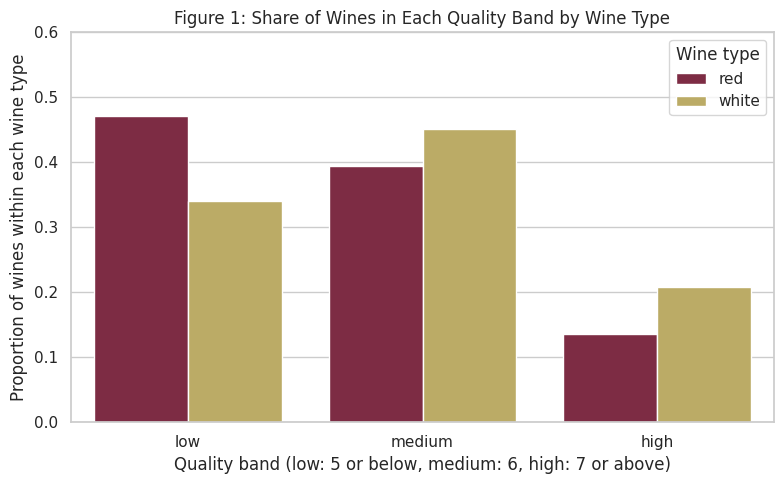

In [12]:
# Figure 1: distribution of quality bands by wine type
band_share = (clean_df.groupby("wine_type")["quality_band"]
              .value_counts(normalize=True).rename("proportion").reset_index())

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=band_share, x="quality_band", y="proportion", hue="wine_type",
            palette={"red": "#8B1E3F", "white": "#C9B458"}, ax=ax)
ax.set_title("Figure 1: Share of Wines in Each Quality Band by Wine Type")
ax.set_xlabel("Quality band (low: 5 or below, medium: 6, high: 7 or above)")
ax.set_ylabel("Proportion of wines within each wine type")
ax.set_ylim(0, 0.6)
ax.legend(title="Wine type")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "figure_1_quality_band_by_type.png"), dpi=150)
plt.show()

**Interpretation of Figure 1.** The bar chart compares the quality profile of red and white wines as proportions, so the different sample sizes do not distort the comparison. About 47 percent of red wines fall in the low band, against 34 percent of white wines, while 21 percent of white wines reach the high band compared with 14 percent of red wines. The medium band is the largest for white wines (45 percent). White wines therefore tend to receive somewhat higher ratings in this sample, although the difference in mean score is small (5.86 for white and 5.62 for red).

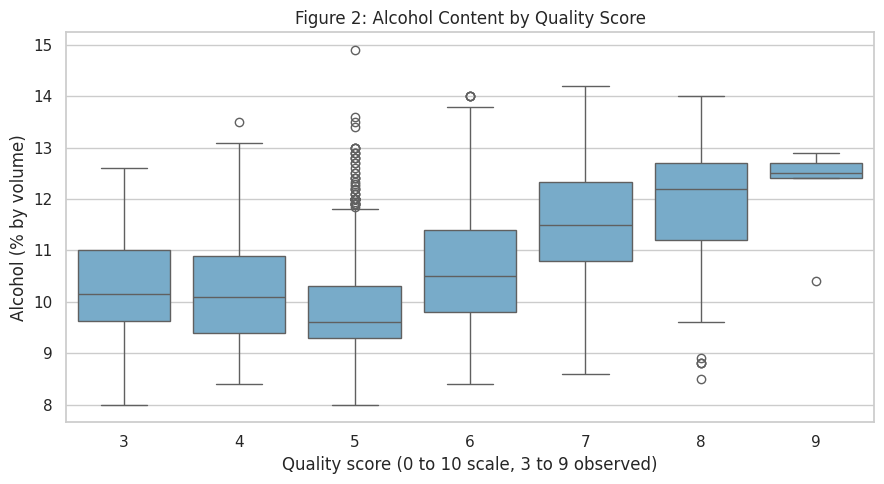

In [13]:
# Figure 2: alcohol content by quality score
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=clean_df, x="quality", y="alcohol", color="#6BAED6", ax=ax)
ax.set_title("Figure 2: Alcohol Content by Quality Score")
ax.set_xlabel("Quality score (0 to 10 scale, 3 to 9 observed)")
ax.set_ylabel("Alcohol (% by volume)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "figure_2_alcohol_by_quality.png"), dpi=150)
plt.show()

**Interpretation of Figure 2.** Each box shows the spread of alcohol content for wines with the same quality score. Median alcohol is lowest for wines scoring 5 (about 9.6 percent), then rises steadily from 10.5 for score 6 to 11.5 for score 7 and 12.2 for score 8. The relationship is not perfectly monotonic at the low end, where scores of 3 and 4 have higher median alcohol than score 5, and the box for score 9 rests on only five wines, so it should not be over-interpreted. Overall the plot supports the positive correlation between alcohol and quality found in the EDA, but the wide boxes and overlap between neighbouring scores show that alcohol alone cannot separate good wines from average ones.

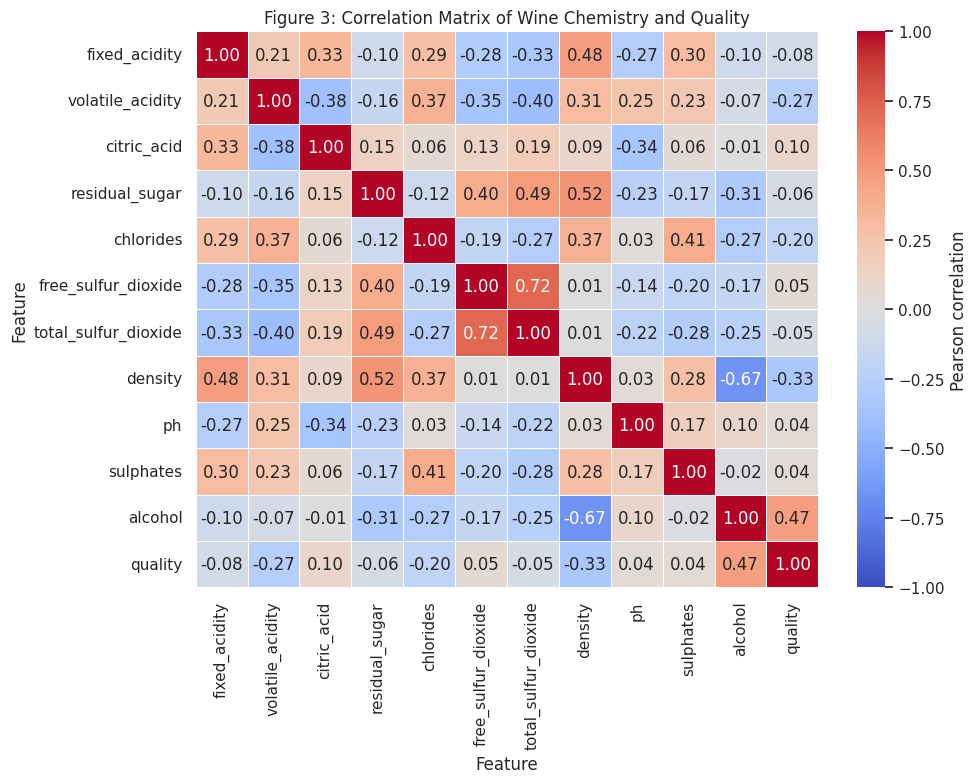

In [14]:
# Figure 3: correlation heatmap of all numeric features
numeric_cols = clean_df.select_dtypes(include="number")
corr_matrix = numeric_cols.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=0.4, cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Figure 3: Correlation Matrix of Wine Chemistry and Quality")
ax.set_xlabel("Feature")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "figure_3_correlation_heatmap.png"), dpi=150)
plt.show()

**Interpretation of Figure 3.** The heatmap shows how every pair of numeric variables is related. The bottom row confirms that alcohol (0.47) is the feature most positively related to quality, followed distantly by citric acid (0.10), while density (-0.33), volatile acidity (-0.27) and chlorides (-0.20) are negatively related. The features are also strongly related to each other: alcohol and density move in opposite directions (-0.67), residual sugar and density move together (0.52), and free and total sulfur dioxide are closely linked (0.72). This multicollinearity matters for later modelling, because several predictors carry overlapping information and their individual effects will be hard to separate.

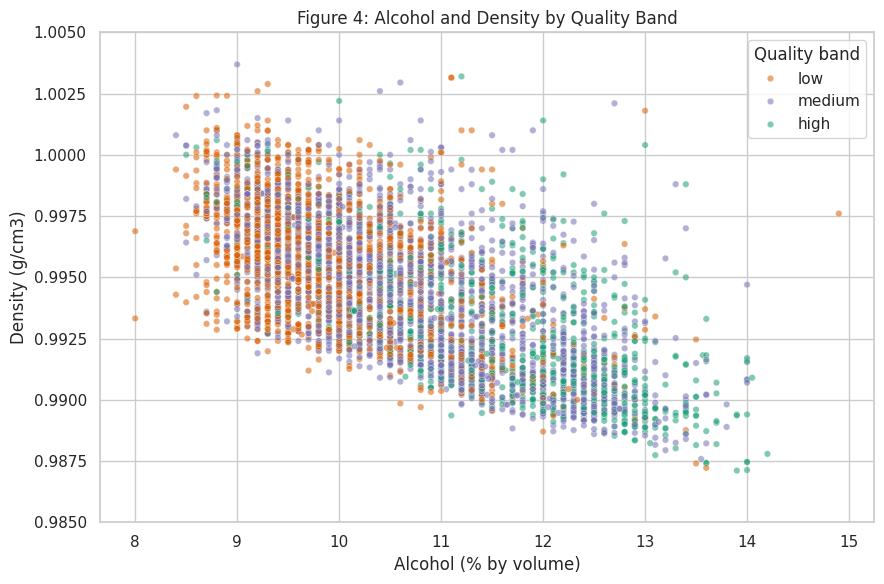

Rows hidden by the y-axis limit: 2


In [15]:
# Figure 4: alcohol against density, coloured by quality band
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=clean_df, x="alcohol", y="density", hue="quality_band",
                palette={"low": "#D95F02", "medium": "#7570B3", "high": "#1B9E77"},
                alpha=0.55, s=22, ax=ax)
ax.set_ylim(0.985, 1.005)  # two extreme density values above 1.005 are hidden for readability
ax.set_title("Figure 4: Alcohol and Density by Quality Band")
ax.set_xlabel("Alcohol (% by volume)")
ax.set_ylabel("Density (g/cm3)")
ax.legend(title="Quality band")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "figure_4_alcohol_density_scatter.png"), dpi=150)
plt.show()
print("Rows hidden by the y-axis limit:", int((clean_df["density"] > 1.005).sum()))

**Interpretation of Figure 4.** The scatter plot shows a clear downward slope: wines with higher alcohol have lower density, which fits the correlation of -0.67 in Figure 3 and is chemically sensible because alcohol is less dense than water. The colours show that high-quality wines (green) cluster towards the high-alcohol, low-density corner, while low-quality wines (orange) cluster towards low alcohol and higher density. The bands overlap heavily in the middle of the plot, so the two measurements together still do not separate quality classes cleanly. Two wines with density above 1.005 are hidden by the axis limit so that the main pattern stays readable; they are retained in the data.

## 6. Summary and Interpretation

**What I learned from the dataset.** The cleaned dataset contains 5,320 Vinho Verde wines, 1,359 red and 3,961 white, described by 11 physicochemical measurements and a sensory quality score. The data needed little cleaning: there were no missing or impossible values, but 1,177 exact duplicate rows were removed and the column names were standardised. A reusable set of functions now handles ingestion, cleaning and EDA, so the same steps can be repeated on new data.

**Interesting patterns and insights.** Alcohol is the clearest signal in the data: higher-alcohol wines tend to receive higher quality scores, and quality rises from a median alcohol of about 9.6 percent at score 5 to about 12.2 percent at score 8. Density, chlorides and volatile acidity are negatively related to quality. White wines are rated slightly higher than red wines on average, and a larger share of red wines fall in the low quality band. The chemical variables are also strongly related to one another, for example alcohol with density and free with total sulfur dioxide.

**Limitations and assumptions.** The quality score is a subjective rating (the median of at least three expert evaluations according to the dataset documentation), so it reflects taste panel judgements as well as chemistry. All wines come from one Portuguese region and the dataset has no information about grape variety, brand or price, so the findings may not generalise to other wines. The classes are imbalanced, with white wines outnumbering red by about three to one and very few wines at the extremes of the quality scale. I assumed that exact duplicate rows were redundant records and removed them, which affected white wines (19.1 percent of rows) more than red wines (15.0 percent). Correlations describe association, not cause, and with several correlated features no single relationship should be treated as an independent effect.

**Surprising or unclear points.** I expected acidity or sugar to matter more, but alcohol and density dominated, and no feature had a correlation with quality above 0.5. It is unclear whether the duplicate rows are data entry errors or genuine repeated samples, and the notebook cannot resolve this without information from the data owners. It is also unclear why wines scoring 3 and 4 have higher median alcohol than wines scoring 5, which may simply reflect the very small number of wines at those scores.